## Ejercicio 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

df = pd.read_csv("../data/raw/guatemala_temperatura.csv", parse_dates=["month"])
df.head()

,month,year,month_num,dewpoint_2m_c,temperature_2m_c,skin_temperature_c,soil_temperature_layer_1_c,soil_temperature_layer_2_c,soil_temperature_layer_3_c,soil_temperature_layer_4_c
0,1950-01-01,1950,1,16.685643,20.762313,21.077662,21.661654,21.679957,21.835225,22.458468
1,1950-02-01,1950,2,15.781276,21.051057,21.518684,22.132758,22.062957,21.964048,22.216061
2,1950-03-01,1950,3,17.330139,23.197594,23.838886,24.374884,24.100146,23.304599,22.380270
3,1950-04-01,1950,4,16.499826,23.661600,24.452373,25.059722,24.752231,24.059086,22.955561
4,1950-05-01,1950,5,19.011177,24.804521,25.501737,26.154377,25.941164,25.252762,23.687375


In [2]:
df.describe()

,month,year,month_num,dewpoint_2m_c,temperature_2m_c,skin_temperature_c,soil_temperature_layer_1_c,soil_temperature_layer_2_c,soil_temperature_layer_3_c,soil_temperature_layer_4_c
count,918,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,1988-03-16 18:29:01.176470,1987.751634,6.480392,18.736168,23.050184,23.443820,24.096186,24.066521,24.010561,23.960867
min,1950-01-01 00:00:00,1950.000000,1.000000,14.198656,18.970146,19.145766,19.837591,19.960146,20.486906,21.566859
25%,1969-02-08 00:00:00,1969.000000,3.000000,17.159645,21.815698,22.066246,22.716301,22.799033,22.936150,23.174425
50%,1988-03-16 12:00:00,1988.000000,6.000000,19.078054,23.256937,23.643262,24.315492,24.274114,24.213858,24.070931
75%,2007-04-23 12:00:00,2007.000000,9.000000,20.337119,24.137825,24.574924,25.215864,25.169290,24.967106,24.638497
max,2026-06-01 00:00:00,2026.000000,12.000000,21.959664,28.686405,29.736339,30.293318,29.804204,28.346901,26.876606
std,NaN,22.096630,3.453879,1.826790,1.568933,1.716298,1.710498,1.599642,1.313116,0.965742


In [3]:
capas = [
    "temperature_2m_c",
    "soil_temperature_layer_1_c",
    "soil_temperature_layer_2_c",
    "soil_temperature_layer_3_c",
    "soil_temperature_layer_4_c",
]

for c_ in capas:
    fmax = df.loc[df[c_].idxmax()]
    fmin = df.loc[df[c_].idxmin()]
    print(f"{c_}: max={fmax[c_]:.2f} ({fmax['month'].date()})  min={fmin[c_]:.2f} ({fmin['month'].date()})")

temperature_2m_c: max=28.69 (2024-05-01)  min=18.97 (1956-01-01)
soil_temperature_layer_1_c: max=30.29 (2024-05-01)  min=19.84 (1956-01-01)
soil_temperature_layer_2_c: max=29.80 (2024-05-01)  min=19.96 (1956-01-01)
soil_temperature_layer_3_c: max=28.35 (2024-05-01)  min=20.49 (1956-01-01)
soil_temperature_layer_4_c: max=26.88 (2024-06-01)  min=21.57 (1976-02-01)


In [4]:
df["t"] = (df["year"] - df["year"].min()) + (df["month_num"] - 1) / 12

for c_ in capas:
    slope, intercept, r, p, se = stats.linregress(df["t"], df[c_])
    print(f"{c_}: {slope:.4f} C/año  (p={p:.4g})")

temperature_2m_c: 0.0171 C/año  (p=1.491e-13)
soil_temperature_layer_1_c: 0.0168 C/año  (p=2.936e-11)
soil_temperature_layer_2_c: 0.0167 C/año  (p=1.301e-12)
soil_temperature_layer_3_c: 0.0166 C/año  (p=6.061e-18)
soil_temperature_layer_4_c: 0.0165 C/año  (p=1.866e-32)


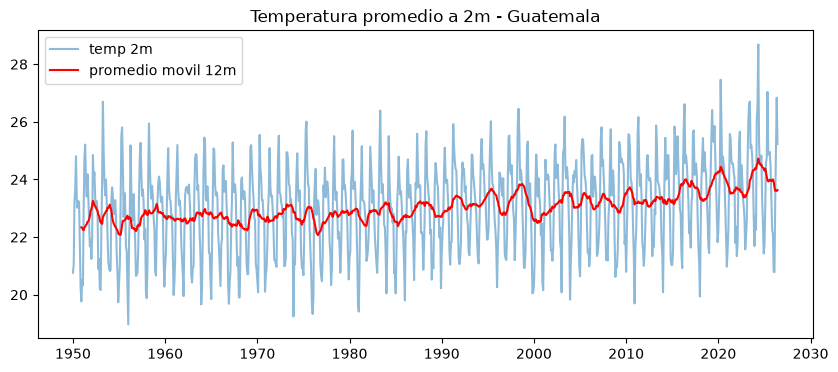

In [5]:
df["temp_2m_rolling"] = df["temperature_2m_c"].rolling(12).mean()
plt.figure(figsize=(10, 4))
plt.plot(df["month"], df["temperature_2m_c"], alpha=0.5, label="temp 2m")
plt.plot(df["month"], df["temp_2m_rolling"], color="red", label="promedio movil 12m")
plt.legend()
plt.title("Temperatura promedio a 2m - Guatemala")
plt.show()

## Ejercicio 2

In [6]:
df = df.sort_values("month").reset_index(drop=True)
train = df.iloc[:-36]
test = df.iloc[-36:]

print("train:", train.shape, train["month"].min().date(), "-", train["month"].max().date())
print("test: ", test.shape, test["month"].min().date(), "-", test["month"].max().date())

train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)

train: (882, 12) 1950-01-01 - 2023-06-01
test:  (36, 12) 2023-07-01 - 2026-06-01


## Ejercicio 3

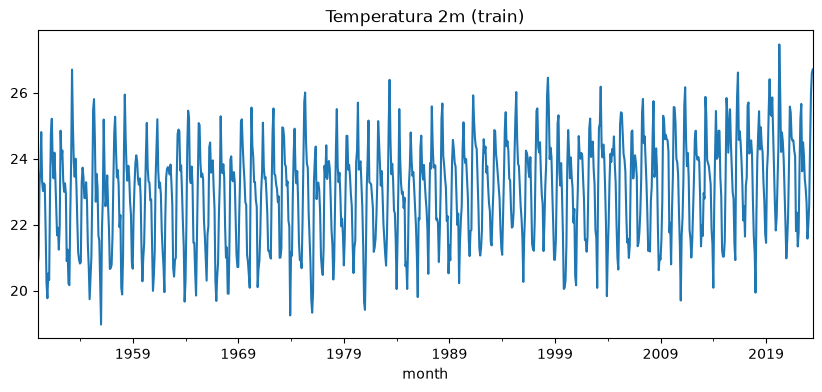

In [7]:
ts = train.set_index("month")["temperature_2m_c"]
ts.index.freq = "MS"
ts.plot(figsize=(10, 4), title="Temperatura 2m (train)")
plt.show()

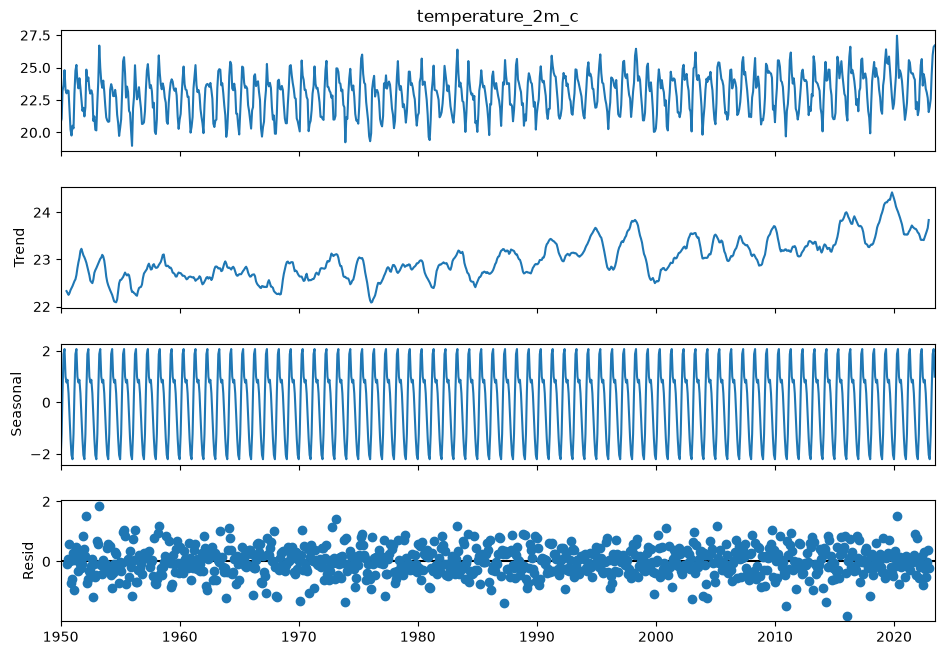

In [8]:
# a) descomposicion
decomp = seasonal_decompose(ts, model="additive", period=12)
decomp.plot()
plt.gcf().set_size_inches(10, 7)
plt.show()

In [9]:
# b) tendencia
t = range(len(ts))
slope, intercept, r, p, se = stats.linregress(t, ts.values)
print(f"pendiente: {slope:.4f} C/mes, p-value: {p:.4g}")

pendiente: 0.0013 C/mes, p-value: 7.219e-11


In [10]:
# c) estacionariedad en media
adf_stat, adf_p, *_ = adfuller(ts)
print("ADF p-value:", adf_p)

kpss_stat, kpss_p, *_ = kpss(ts, regression="c", nlags="auto")
print("KPSS p-value:", kpss_p)

ADF p-value: 0.0003533704889496194
KPSS p-value: 0.01


/tmp/ipykernel_132529/4077656035.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(ts, regression="c", nlags="auto")


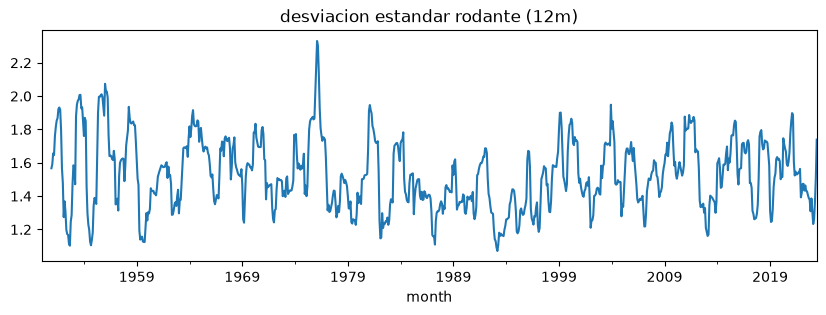

var primera mitad: 2.3194500150420665
var segunda mitad: 2.2705707017682437


In [11]:
# estacionariedad en varianza
ts.rolling(12).std().plot(figsize=(10, 3), title="desviacion estandar rodante (12m)")
plt.show()

mitad = len(ts) // 2
print("var primera mitad:", ts.iloc[:mitad].var())
print("var segunda mitad:", ts.iloc[mitad:].var())

## Ejercicio 4

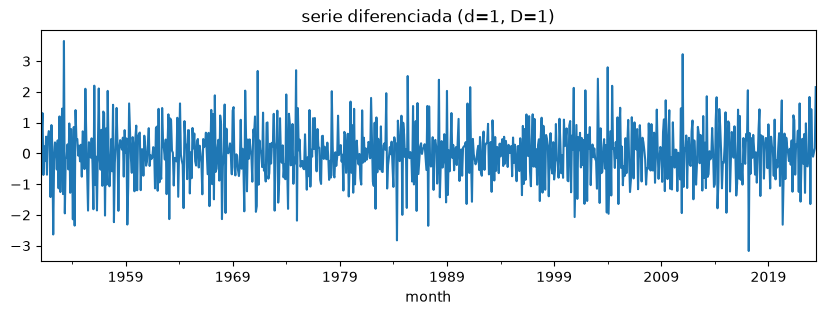

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# la varianza ya era estable, solo hay que diferenciar para quitar tendencia y estacionalidad
ts_diff = ts.diff().diff(12).dropna()
ts_diff.plot(figsize=(10, 3), title="serie diferenciada (d=1, D=1)")
plt.show()

In [13]:
# verificar que ya es estacionaria en media
adf_stat, adf_p, *_ = adfuller(ts_diff)
print("ADF p-value:", adf_p)

kpss_stat, kpss_p, *_ = kpss(ts_diff, regression="c", nlags="auto")
print("KPSS p-value:", kpss_p)

ADF p-value: 9.05065585476656e-26
KPSS p-value: 0.1


/tmp/ipykernel_132529/2760701597.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(ts_diff, regression="c", nlags="auto")


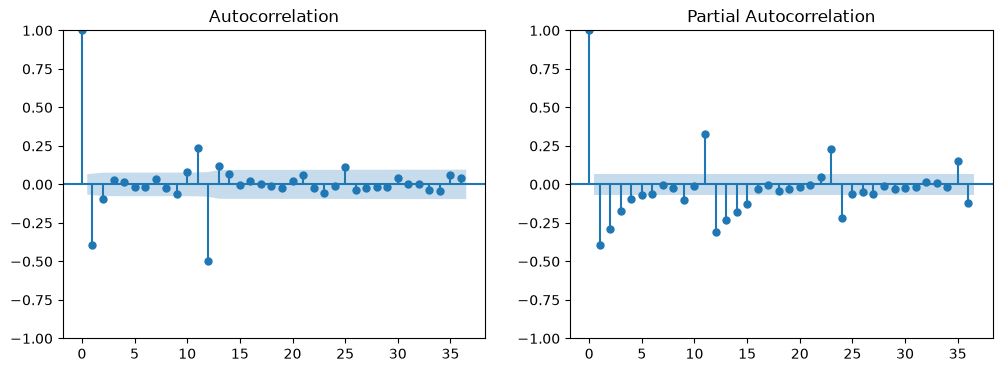

In [14]:
# ACF y PACF para estimar p y q
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts_diff, lags=36, ax=axes[0])
plot_pacf(ts_diff, lags=36, ax=axes[1])
plt.show()

In [15]:
# modelo 1: SARIMA(1,1,1)(1,1,1,12) segun lo que se ve en ACF/PACF
modelo1 = SARIMAX(ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
print(modelo1.summary().tables[0])
print("AIC:", modelo1.aic)

                                     SARIMAX Results                                      
Dep. Variable:                   temperature_2m_c   No. Observations:                  882
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -727.988
Date:                            Thu, 16 Jul 2026   AIC                           1465.976
Time:                                    18:23:55   BIC                           1489.813
Sample:                                01-01-1950   HQIC                          1475.097
                                     - 06-01-2023                                         
Covariance Type:                              opg                                         
AIC: 1465.9762170425192


In [16]:
# modelo 2: mas rezagos AR
modelo2 = SARIMAX(ts, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
print("AIC:", modelo2.aic)

/home/DiegoPatzan/Documents/UVG/DATA/EJERCICIO1/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AIC: 1445.4014183337165


In [17]:
# modelo 3: sin diferenciacion regular, solo la estacional
modelo3 = SARIMAX(ts, order=(1, 0, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
print("AIC:", modelo3.aic)

AIC: 1451.5776793247771


In [18]:
print("modelo1 SARIMA(1,1,1)(1,1,1,12) AIC:", round(modelo1.aic, 2))
print("modelo2 SARIMA(2,1,2)(1,1,1,12) AIC:", round(modelo2.aic, 2))
print("modelo3 SARIMA(1,0,1)(0,1,1,12) AIC:", round(modelo3.aic, 2))

modelo1 SARIMA(1,1,1)(1,1,1,12) AIC: 1465.98
modelo2 SARIMA(2,1,2)(1,1,1,12) AIC: 1445.4
modelo3 SARIMA(1,0,1)(0,1,1,12) AIC: 1451.58


## Ejercicio 5

In [19]:
# a) significacion de los coeficientes (valido el modelo2, el de mejor AIC)
print(modelo2.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7850      0.157      5.005      0.000       0.478       1.092
ar.L2         -0.0156      0.071     -0.219      0.826      -0.155       0.124
ma.L1         -1.5074      0.156     -9.679      0.000      -1.813      -1.202
ma.L2          0.5123      0.153      3.344      0.001       0.212       0.812
ar.S.L12      -0.0583      0.035     -1.662      0.096      -0.127       0.010
ma.S.L12      -0.9418      0.016    -57.224      0.000      -0.974      -0.910
sigma2         0.2934      0.013     22.209      0.000       0.267       0.319


In [20]:
import numpy as np

# raices AR y MA: deben estar fuera del circulo unitario y no ser casi iguales entre si
print("raices AR:", np.abs(modelo2.arroots))
print("raices MA:", np.abs(modelo2.maroots))

raices AR: [ 1.26715792  1.26715792  1.26715792  1.26715792  1.26715792  1.26715792
  1.26715792  1.26715792  1.26715792  1.26715792  1.26715792  1.26715792
  1.30799544 48.94732113]
raices MA: [1.00501044 1.00501044 1.00501044 1.00501044 1.00501044 1.00501044
 1.00501044 1.00501044 1.00501044 1.00501044 1.00501044 1.00501044
 1.01025477 1.93227879]


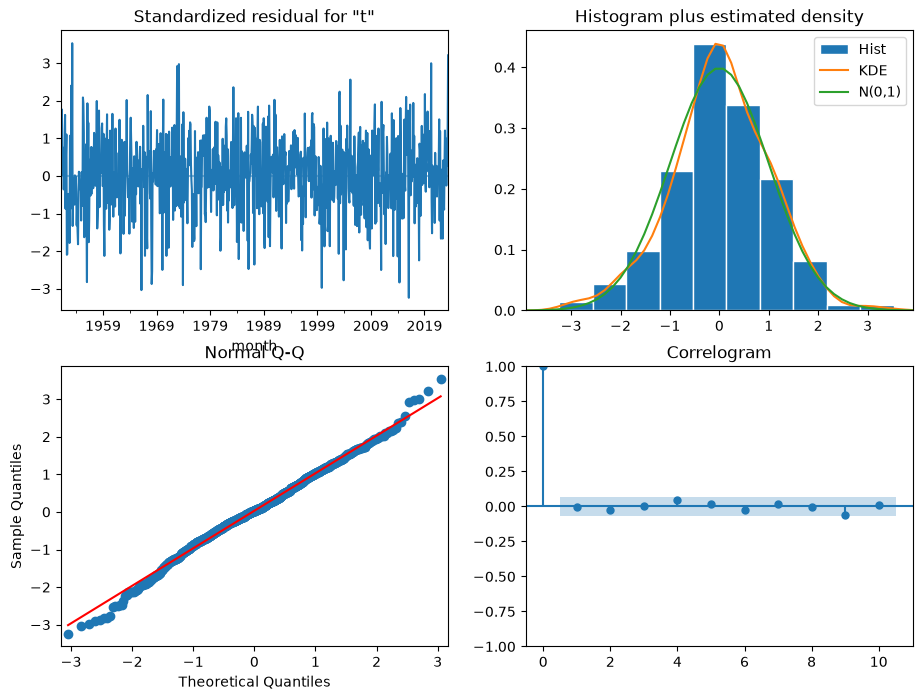

In [21]:
# b) diagnostico de residuos
modelo2.plot_diagnostics(figsize=(11, 8))
plt.show()

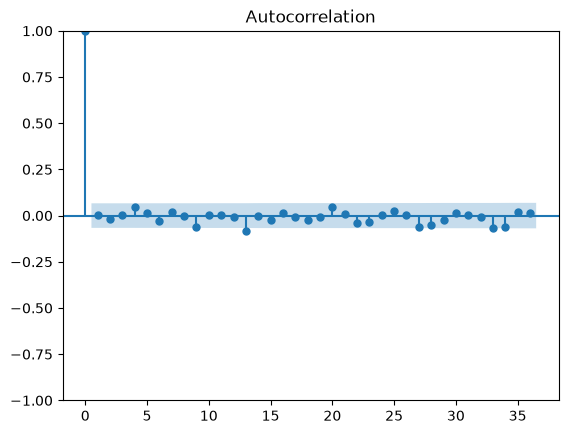

,lb_stat,lb_pvalue
12,7.002743,0.857432
24,18.810424,0.762023
36,33.569688,0.584730


In [22]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = modelo2.resid[13:]  # se saltan los primeros valores afectados por la diferenciacion
plot_acf(resid, lags=36)
plt.show()
acorr_ljungbox(resid, lags=[12, 24, 36])

In [23]:
# c) comparacion con los modelos alternativos
for nombre, m in [("modelo1", modelo1), ("modelo2", modelo2), ("modelo3", modelo3)]:
    print(f"{nombre}: AIC={m.aic:.2f}  BIC={m.bic:.2f}")

modelo1: AIC=1465.98  BIC=1489.81
modelo2: AIC=1445.40  BIC=1478.77
modelo3: AIC=1451.58  BIC=1470.65


## Ejercicio 6

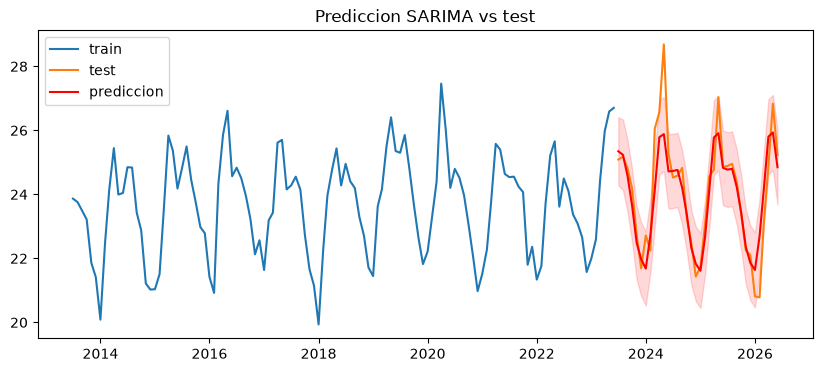

In [24]:
ts_test = test.set_index("month")["temperature_2m_c"]
ts_test.index.freq = "MS"

pred = modelo2.get_forecast(36)
pred_media = pred.predicted_mean
ci = pred.conf_int()

plt.figure(figsize=(10, 4))
plt.plot(ts[-120:], label="train")
plt.plot(ts_test, label="test")
plt.plot(pred_media, label="prediccion", color="red")
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="red", alpha=0.15)
plt.legend()
plt.title("Prediccion SARIMA vs test")
plt.show()

In [25]:
rmse_sarima = np.sqrt(((ts_test - pred_media) ** 2).mean())
mae_sarima = (ts_test - pred_media).abs().mean()
print(f"RMSE: {rmse_sarima:.3f}  MAE: {mae_sarima:.3f}")

RMSE: 0.834  MAE: 0.580
